# Análisis de marketing rendimiento y rentabilidad
## Descripción de los datos

El análisis se basa en tres conjuntos de datos proporcionados por la empresa, los cuales contienen información sobre las visitas al sitio web, los pedidos realizados por los usuarios y los gastos de marketing.

### Tabla `visits`
Registros del servidor con datos sobre las visitas al sitio web.

- `Uid`: identificador único del usuario.
- `Device`: dispositivo del usuario.
- `Start Ts`: fecha y hora de inicio de la sesión.
- `End Ts`: fecha y hora de término de la sesión.
- `Source Id`: identificador de la fuente de anuncios de la que proviene el usuario.

Todas las fechas de esta tabla están registradas en formato `YYYY-MM-DD`.

### Tabla `orders`
Datos sobre los pedidos realizados por los usuarios.

- `Uid`: identificador único del usuario que realiza un pedido.
- `Buy Ts`: fecha y hora del pedido.
- `Revenue`: ingreso obtenido por cada pedido.

### Tabla `costs`
Datos sobre los gastos de marketing.

- `source_id`: identificador de la fuente de anuncios.
- `dt`: fecha.
- `costs`: gastos en esta fuente de anuncios en este día.


*Cabe mencionar que más adelante en el preprocesamiento de los datos se estandarizaron los nombre de las columnas a snake_case para facilitar su analisis.*

In [1]:
# Importar Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar los datasets
visits = pd.read_csv("visits_log_us.csv")
orders = pd.read_csv("orders_log_us.csv")
costs = pd.read_csv("costs_us.csv")

# Shape para verificar que se haya cargado correctamente
print("Shape de Visits:", visits.shape)
print("Shape de Orders:", orders.shape)
print("Shape de Costs:", costs.shape)

Shape de Visits: (359400, 5)
Shape de Orders: (50415, 3)
Shape de Costs: (2542, 3)


## Preprocesamiento de datos

In [3]:
# Leer primeras lineas del dataset visits
print(visits.head())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  


In [4]:
# Revisar el tipo de datos del dataset visits
print(visits.info())

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 13.7 MB
None


In [5]:
# Estandarización de nombres de columnas a snake_case en dataset visits
visits.columns = (
    visits.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# imprimir para confirmar el cambio
print(visits.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='str')


In [6]:
# Convertir columnas "end_ts" y "start_ts" a datetime en dataset visits
visits[['start_ts', 'end_ts']] = visits[[
    'start_ts', 'end_ts']].apply(pd.to_datetime)

# Imprimir info para confirmar el cambio
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  str           
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[us]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[us](2), int64(1), str(1), uint64(1)
memory usage: 13.7 MB


In [7]:
# Leer primeras lineas del dataset orders
print(orders.head())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


In [8]:
# Revisar el tipo de datos del dataset orders
print(orders.info())

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  str    
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), str(1), uint64(1)
memory usage: 1.2 MB
None


In [9]:
# Estandarización de nombres de columnas a snake_case en dataset orders
orders.columns = (
    orders.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# imprimir para confirmar el cambio
print(orders.columns)

Index(['buy_ts', 'revenue', 'uid'], dtype='str')


In [10]:
# Convertir columna "buy_ts" a datetime en dataset orders
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

# Imprimir info para confirmar el cambio
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[us]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [11]:
# Leer primeras lineas del dataset costs
print(costs.head())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


In [12]:
# Revisar el tipo de datos del dataset costs
print(costs.info())

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   str    
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 59.7 KB
None


In [13]:
# Convertir columna "ts" a datetime en dataset costs
costs["dt"] = pd.to_datetime(costs["dt"])

# Imprimir info para confirmar el cambio
costs.info()

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 59.7 KB


## Exploratory Data Analysis (EDA)

## Parte 1 Análisis de Visitas:
- ¿Cuántas personas usan el servicio cada día, semana y mes?
- ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
- ¿Cuál es la duración de cada sesión?
- ¿Con qué frecuencia regresan los usuarios?

In [14]:
# Calculo de las metricas "DAU", "WAU", "MAU" en respuesta a la preugnta ¿Cuántas personas usan el serivcio cada día, semana y mes?


# agregar una columna para año, semana, mes y fecha al dataframe visits
visits["session_year"] = visits["start_ts"].dt.isocalendar().year
visits["session_month"] = visits["start_ts"].dt.month
visits["session_week"] = visits["start_ts"].dt.isocalendar().week
visits["session_date"] = visits["start_ts"].dt.date

# Calculo del "DAU"
dau = visits.groupby("session_date").agg({"uid": "nunique"})
dau_total = visits.groupby("session_date").agg({"uid": "nunique"}).mean()

# Calculo de "WAU"
wau = visits.groupby(["session_year", "session_week"]).agg({"uid": "nunique"})
wau_total = visits.groupby(["session_year", "session_week"]).agg({
    "uid": "nunique"}).mean()

# Calculo del "MAU"
mau = visits.groupby(["session_year", "session_month"]).agg({"uid": "nunique"})
mau_total = visits.groupby(["session_year", "session_month"]).agg({
    "uid": "nunique"}).mean()

print(f"""
dau_total: {dau_total.iloc[0]:.2f}

wau_total: {wau_total.iloc[0]:.2f}

mau_total: {mau_total.iloc[0]:.2f};
""")


dau_total: 907.99

wau_total: 5716.25

mau_total: 23228.42;



In [15]:
# Calculo del numero de sessiones por día en respuesta a la pregunta ¿Cuántas sesiones hay por día?

sessions_per_day = visits.groupby("session_date").agg({"uid": "count"})
sessions_per_day.columns = ["num_sessions"]

print(
    f"Número de sesiones por día promedio:, {sessions_per_day.mean().iloc[0]:.2f}")

Número de sesiones por día promedio:, 987.36


count    359398.000000
mean        643.042287
std         997.105212
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
dtype: float64

moda: 60.0


<Axes: >

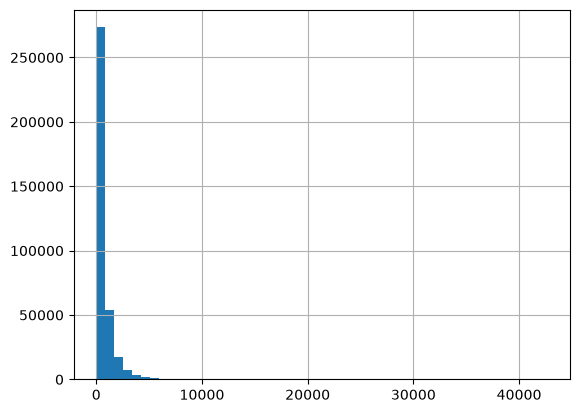

In [16]:
# Calculo de la duración por session promedio

session_duration = (visits["end_ts"] - visits["start_ts"]).dt.total_seconds()

session_duration = session_duration[session_duration >= 0]
print(session_duration.describe())
print()
print(f"moda: {session_duration.mode().iloc[0]}")

session_duration.hist(bins=50)

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

**Interpretación duración de sesiones.**
- La distribución de la duración de las sesiones presenta un sesgo positivo (cola hacia la derecha), por lo que el promedio se ve afectado por valores extremos y no representa adecuadamente el comportamiento típico.
- La moda (60 segundos), aunque es el valor más frecuente, puede reflejar sesiones muy breves y no necesariamente el tiempo habitual de interacción del usuario.
- Dado lo anterior, la mediana se considera una medida más representativa para describir la duración típica de una sesión.
</div>

In [17]:

# Calculo del "STICKY WAU" y "STICKY MAU" en respuesta a la pregunta ¿Con qué frecuencia regresan los usuarios?

sticky_wau = (dau_total / wau_total) * 100


sticky_mau = (dau_total / mau_total) * 100

print(f"STICKY WAU: {sticky_wau.iloc[0]:.2f}")
print(f"STICKY MAU:{sticky_mau.iloc[0]:.2f}")

STICKY WAU: 15.88
STICKY MAU:3.91


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## **Conclusiones de Parte 1 Análisis de Visitas.**

- El servicio presenta un promedio de aproximadamente 900 usuarios activos diarios, lo que escala a más de 5,700 usuarios activos semanales y cerca de 23,200 usuarios activos mensuales. Esta relación sugiere que una proporción significativa de los usuarios interactúa con el servicio de forma recurrente a lo largo del mes. <br>
El promedio de usuarios activos diarios (\~900) no se multiplica directamente por siete para obtener el número de usuarios activos semanales (\~5,700), ya que los mismos usuarios pueden interactuar con el servicio en varios días de la semana. Esta diferencia indica un comportamiento recurrente, donde una parte de los usuarios regresa varias veces durante el período analizado, lo que sugiere un nivel estable de engagement semanal.
- La similitud entre el número de usuarios activos diarios y el número de sesiones diarias muestra que la mayoría de los usuarios accede al servicio una sola vez al día, en lugar de realizar múltiples sesiones en el mismo día. Este patrón es consistente con un servicio de venta de entradas y sugiere que la oportunidad de conversión ocurre en un único momento diario, por lo que las estrategias de marketing deberían enfocarse en impactar al usuario cuando existe intención de compra, más que en incentivar múltiples accesos dentro del mismo día.
- La duración de las sesiones presenta una distribución sesgada hacia valores altos, lo que evidencia la existencia de algunas sesiones prolongadas. No obstante, la mediana (\~300 segundos) indica que el comportamiento típico de los usuarios consiste en interacciones relativamente breves, de aproximadamente cinco minutos. Esto sugiere que los usuarios acceden al servicio con un objetivo específico y toman decisiones en un periodo de tiempo corto.<br>
Este patrón refuerza la importancia de ofrecer una experiencia clara y eficiente desde el primer contacto, dado que el tiempo habitual de interacción es limitado.
- El análisis de stickiness muestra que aproximadamente el 16% de los usuarios activos semanales interactúan con el servicio en un día determinado, mientras que solo cerca del 4% de los usuarios activos mensuales lo hacen diariamente. Esto confirma que el uso del servicio no es de carácter diario para la mayoría de los usuarios, sino que responde a una necesidad puntual, consistente con un modelo de negocio basado en la compra de entradas para eventos.
</div>

## Parte 2 Analisis de Ventas:
- ¿Cuándo empieza la gente a comprar?
    - Tiempo que transcurre entre el registro y la conversión
    - Comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.
- ¿Cuántos pedidos hacen durante un período de tiempo dado?
- ¿Cuál es el tamaño promedio de compra?
- ¿Cuánto dinero traen? (LTV)

In [18]:
# Definición de cohortes según el mes de la primera visita al sitio

# Definir la fecha de la primero visita
first_visit = visits.groupby("uid")["start_ts"].min().reset_index()
first_visit.columns = ["uid", "first_visit"]

# Agregar la fecha de la primera visita al dataframe visits
visits = visits.merge(first_visit, on="uid", how="left")

In [19]:
# Agregar el mes de la cohort
visits["first_visit_month"] = visits["first_visit"].dt.to_period("M")


print(visits.head())

    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    uid  session_year  session_month  session_week  \
0  16879256277535980062          2017             12            51   
1    104060357244891740          2018              2             8   
2   7459035603376831527          2017              7            26   
3  16174680259334210214          2018              5            20   
4   9969694820036681168          2017             12            52   

  session_date         first_visit first_visit_month  
0   2017-12-20 2017-12-20 17:20:00           2017-12  
1   2018-02-19 2018-02-19 16:53:00           2018-02  
2   2017-07-01 2017-07-

In [20]:
# Definir fecha de la primera compra
first_purchase = orders.groupby("uid")["buy_ts"].min().reset_index()
first_purchase.columns = ["uid", "first_purchase"]


# añadir la fecha de la primera compra al dataframe visits
visits = visits.merge(first_purchase, on="uid", how="left")

# print(first_purchase.head())

print(visits.head())

    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    uid  session_year  session_month  session_week  \
0  16879256277535980062          2017             12            51   
1    104060357244891740          2018              2             8   
2   7459035603376831527          2017              7            26   
3  16174680259334210214          2018              5            20   
4   9969694820036681168          2017             12            52   

  session_date         first_visit first_visit_month      first_purchase  
0   2017-12-20 2017-12-20 17:20:00           2017-12                 NaT  
1   2018-02-19 2018-02-19 16:53:00    

In [21]:
# Unir datos de la primera visita y la primer compra
first_data = first_visit.merge(first_purchase, on="uid", how="left")

# Calcular tiempo entre primer visita y primer compra
first_data["conversion_days"] = (
    first_data["first_purchase"] - first_data["first_visit"]
).dt.days

print(first_data.head())

               uid         first_visit      first_purchase  conversion_days
0   11863502262781 2018-03-01 17:27:00                 NaT              NaN
1   49537067089222 2018-02-06 15:55:00                 NaT              NaN
2  297729379853735 2017-06-07 18:47:00                 NaT              NaN
3  313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00            106.0
4  325320750514679 2017-09-30 14:29:00                 NaT              NaN


count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64


<Axes: >

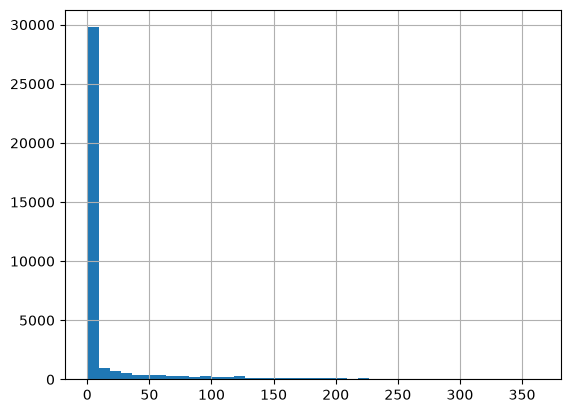

In [22]:
# Analizar datos de first_data

print(first_data["conversion_days"].describe())

first_data["conversion_days"].hist(bins=40)

In [23]:
# Analisis de conversion

# Obtención de los valores de los distintos canales
print(visits["source_id"].unique())
print(costs["source_id"].unique())

[ 4  2  5  9  3  1 10  7  6]
[ 1  2  3  4  5  9 10]


In [24]:
# Crear dataframe necesario para analizar conversiones por canal
visits_clean = (
    visits[visits["start_ts"] == visits["first_visit"]]
    .drop_duplicates(subset="uid")
)

In [25]:
# tasa de conversion total
total_conversion_rate = (
    visits_clean["first_purchase"].notna().mean() * 100).round(2)


# Número de usuarios unicos que realizaron una visita
print(f"""
- Número de usuarios que visitaron la pagina: {len(visits_clean)}
- Tasa de conversión: {total_conversion_rate}
- Número de usuarios que convirtieron: {visits_clean["first_purchase"].notna().sum()}""")


- Número de usuarios que visitaron la pagina: 228169
- Tasa de conversión: 16.01
- Número de usuarios que convirtieron: 36523


In [26]:
# Analizar conversión por cohort
cohort_conversion = (
    visits_clean
    .groupby("first_visit_month")["first_purchase"]
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

cohort_conversion

first_visit_month
2017-06    22.05
2017-07    18.71
2017-08    16.90
2017-09    18.31
2017-10    18.01
2017-11    15.64
2017-12    16.12
2018-01    13.79
2018-02    14.35
2018-03    13.78
2018-04    12.03
2018-05    15.16
Freq: M, Name: first_purchase, dtype: float64

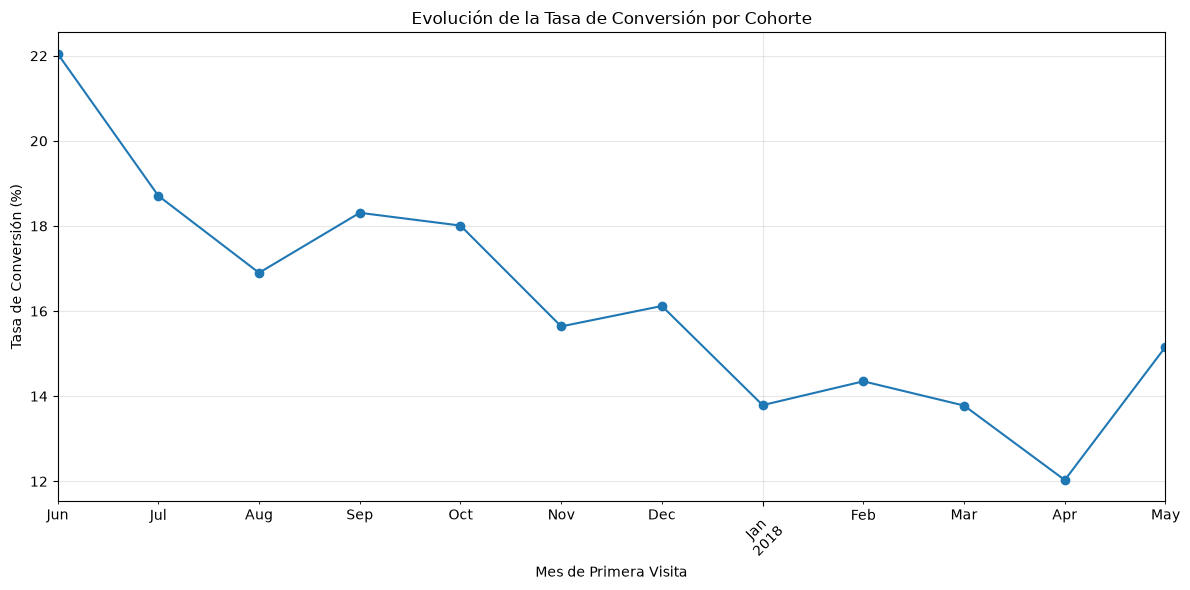

In [27]:
# Gráfico de evolución temporal de conversión por cohorte
plt.figure(figsize=(12, 6))
cohort_conversion.plot(kind='line', marker='o')
plt.title('Evolución de la Tasa de Conversión por Cohorte')
plt.xlabel('Mes de Primera Visita')
plt.ylabel('Tasa de Conversión (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Calcular tasa de conversión por canal de marketing
conversion_by_source = (
    visits_clean
    .groupby("source_id")["first_purchase"]
    .apply(lambda x: x.notna().mean() * 100)
    .sort_values(ascending=False)
    .round(2)
).reset_index()

conversion_by_source.columns = ["source_channel", "conversion_rate"]


# convertir canales a texto para graficar correctamente
conversion_by_source["source_channel"] = "Channel " + \
    conversion_by_source["source_channel"].astype("str")


conversion_by_source

,source_channel,conversion_rate
0,Channel 1,30.62
1,Channel 2,19.90
2,Channel 10,19.25
3,Channel 9,16.87
4,Channel 3,15.84
5,Channel 4,14.23
6,Channel 5,14.08
7,Channel 7,3.12
8,Channel 6,0.00


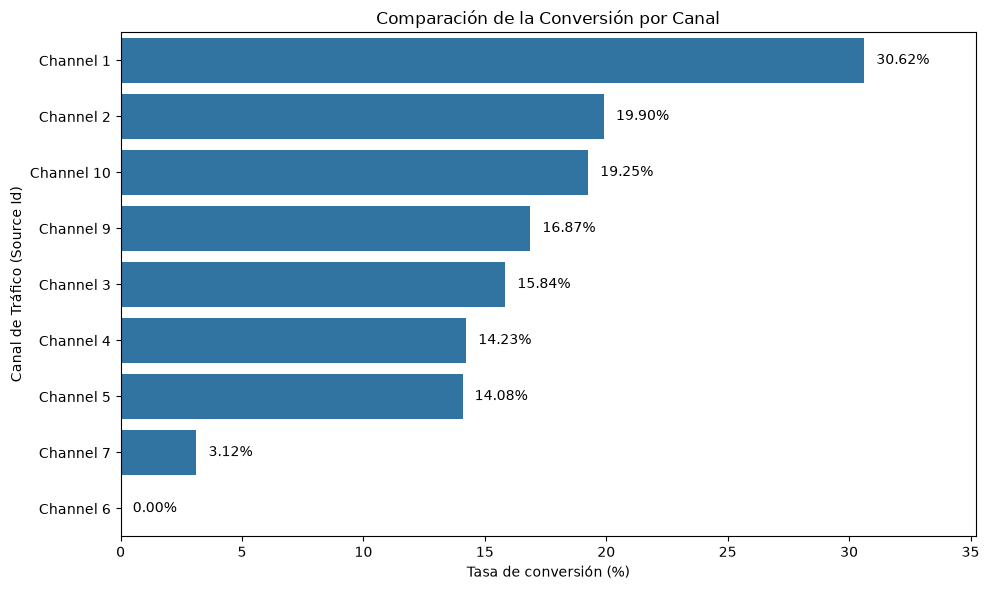

In [29]:

# Grafico de comparación de tasas de convesión por canal
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=conversion_by_source,
    y='source_channel',
    x='conversion_rate'
)

# Agregar valores al final de cada barra
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}%',
        va='center'
    )

ax.set_xlim(0, conversion_by_source['conversion_rate'].max() * 1.15)

plt.xlabel('Tasa de conversión (%)')
plt.ylabel('Canal de Tráfico (Source Id)')
plt.title('Comparación de la Conversión por Canal')

plt.tight_layout()
plt.show()

In [30]:
# Analisis para contestar a la pregunta ¿Cuántos pedidos hacen durante un período de tiempo dado?

# Pedidos totales por mes
orders["order_month"] = orders["buy_ts"].dt.to_period("M")

orders_per_month = (
    orders
    .groupby("order_month")["uid"]
    .count()
)

orders_per_month

order_month
2017-06    2354
2017-07    2363
2017-08    1807
2017-09    3387
2017-10    5679
2017-11    5659
2017-12    6218
2018-01    4721
2018-02    5281
2018-03    5326
2018-04    3273
2018-05    4346
2018-06       1
Freq: M, Name: uid, dtype: int64

In [31]:
# Pedidos por usuario
orders_per_user = (
    orders
    .groupby("uid")["buy_ts"]
    .count()
)

orders_per_user.describe()

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: buy_ts, dtype: float64

In [32]:
monthly_orders = (
    orders
    .groupby(["order_month", "uid"])
    .size()
    .groupby("order_month")
    .mean()
)

monthly_orders

order_month
2017-06    1.163618
2017-07    1.191028
2017-08    1.227582
2017-09    1.231636
2017-10    1.214759
2017-11    1.244557
2017-12    1.258195
2018-01    1.211134
2018-02    1.240254
2018-03    1.273858
2018-04    1.192784
2018-05    1.226298
2018-06    1.000000
Freq: M, dtype: float64

In [33]:
# Analisis para responder la pregunta ¿Cuál es el tamaño promedio de compra?
# Tamaño promedio de compra
orders["revenue"].describe()

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: revenue, dtype: float64

In [34]:
# Analisis de quantiles para observar los outlier en revenue
orders["revenue"].quantile([0.90, 0.95, 0.99])

0.90     9.17
0.95    13.75
0.99    36.67
Name: revenue, dtype: float64

In [35]:
# Analisis en respuesta a la pregunta ¿Cuánto dinero traen? (LTV)

In [36]:
total_revenue = orders["revenue"].sum().round(2)
print("Ingreso Total:", total_revenue)

# Calculo del "LTV" con todos los datos
ltv = (orders.groupby("uid")["revenue"].sum().mean()).round(2)
print("LTV:", ltv)

# Eliminar los outliers en revenue para no afectar el LTV
q99 = orders["revenue"].quantile(0.99)
orders["revenue_capped"] = orders["revenue"].clip(upper=q99)


ltv_capped = (orders.groupby("uid")["revenue_capped"].sum().mean()).round(2)

print("LTV SIN OUTLIERS:", ltv_capped)

Ingreso Total: 252057.2
LTV: 6.9
LTV SIN OUTLIERS: 5.94


In [37]:
# LTV por canal de marketing
# Primero, obtener el canal de cada usuario (de su primera visita)
user_source = visits_clean[['uid', 'source_id']].copy()

# Unir orders con el canal de cada usuario
orders_with_source = orders.merge(user_source, on='uid', how='left')

# Calcular LTV por canal
ltv_by_source = (
    orders_with_source
    .groupby(['source_id', 'uid'])['revenue'].sum()
    .groupby('source_id').mean()
    .round(2)
    .sort_values(ascending=False)
).reset_index()

ltv_by_source.columns = ["source_id", "ltv"]
print("LTV por canal:")
ltv_by_source

LTV por canal:


,source_id,ltv
0,2,13.38
1,1,10.72
2,5,7.59
3,4,5.51
4,9,5.29
5,3,5.20
6,10,3.35
7,7,1.22


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## Conclusiones Parte 2 Análisis de Ventas

- El análisis muestra que la conversión ocurre principalmente de forma inmediata: la mediana de tiempo hasta la primera compra es de 0 días y el 75% de los usuarios se convierte dentro de los primeros 2 días. Esto indica un ciclo de decisión corto y una alta intención de compra desde la primera visita. <br>

- El análisis de cohortes muestra diferencias relevantes en la tasa de conversión según el mes de adquisición. Las cohortes de junio (22.05%) y julio de 2017 (18.71%) presentan los niveles más altos de conversión, mientras que las cohortes de 2018 muestran una tendencia general a la baja, con valores entre 12% y 15%. <br>
Esto indica que los usuarios adquiridos en los primeros meses analizados tuvieron mayor probabilidad de compra, lo que sugiere una posible disminución en la calidad del tráfico o cambios en la efectividad de las estrategias de adquisición durante 2018.

- La comparación de tasas de conversión muestra diferencias claras en la efectividad de los canales de marketing. Channel 1 es el canal más efectivo, con una tasa de conversión de 30.61%, posicionándose como la principal fuente de adquisición con mayor probabilidad de generar compradores. <br>
En un segundo nivel de desempeño se encuentran Channel 2 (19.90%) y Channel 10 (19.25%), que también presentan resultados sólidos, aunque considerablemente menores que Channel 1.
Por debajo se ubican Channel 9, 3, 4 y 5 con tasas de conversión entre el 14 % y 16.87 %. <br>
Y por ultimo tenemos Channel 7 (3.12%) y Channel 6 (0%) muestran un rendimiento significativamente bajo o nulo.
- Durante el período analizado (junio 2017 – mayo 2018), la plataforma genera en promedio ≈4,000 pedidos mensuales, con una variación entre aproximadamente 1,800 y 6,200 pedidos por mes. Se observa un crecimiento progresivo hacia finales de 2017, alcanzando su punto máximo en diciembre, lo que sugiere un posible efecto estacional.
En 2018 el volumen se mantiene relativamente estable, aunque con ligeras fluctuaciones y menores volúmenes de conversión. <br>
A nivel individual, el comportamiento es marcadamente no recurrente:
    - La mediana es 1 pedido por usuario.
    - El 75% de los usuarios realiza solo 1 compra.
    - El promedio es 1.38 pedidos por usuario. <br><br>

   Esto indica que el volumen total de pedidos depende principalmente de la adquisición constante de nuevos usuarios, más que de la repetición de compra. La recurrencia es baja y existe una fuerte concentración en compras únicas.

- El tamaño promedio de compra es 5.0, pero este valor está influenciado por un pequeño número de pedidos de alto monto. <br>
La mediana es 2.5, lo que indica que la mayoría de los clientes realiza compras pequeñas. Además, el 90% de las compras no supera 9.17, y el 99% no supera 36.67.
En términos prácticos, el comportamiento típico de compra es de bajo valor, con pocos casos atípicos que elevan el promedio general. <br>
Esto implica que el modelo de negocio depende principalmente del volumen de transacciones para generar ingresos relevantes, más que del alto valor individual de cada pedido.

- El ingreso total del periodo analizado es de \$ 252,057.2

- El LTV promedio por usuario es 6.9, lo que indica que, en promedio, cada cliente genera aproximadamente 6.9 unidades monetarias a lo largo de su relación con la empresa. <br>
Al ajustar el cálculo excluyendo valores atípicos superiores (top 1%), el LTV se reduce a 5.94, lo que confirma que una pequeña proporción de usuarios con compras excepcionalmente altas eleva el promedio general.<br>
A nivel de canal, existen diferencias relevantes:
    - Canal 2 presenta el LTV más alto (~13.38), seguido de
    - Canal 1 (~10.72)
    - Canal 5 (~7.59)
    - Mientras que otros canales generan valores significativamente menores (entre ~5.35 y  ~1.22).<br><br>

    En términos estratégicos:<br>
    El negocio genera un LTV moderado y relativamente bajo por usuario, consistente con un modelo basado en volumen. <br>
    La rentabilidad dependerá de mantener una adquisición eficiente (CAC bajo) y escalar los canales con mayor LTV. <br>
    No todos los canales aportan el mismo valor económico, por lo que la inversión debe priorizar aquellos con mayor LTV relativo. <br>
    El siguiente paso crítico es contrastar estos valores contra el CAC por canal para evaluar rentabilidad real.

</div>

## Parte 3 Análisis de Marketing:
 - ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 
 - ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
 - ¿Cuán rentables eran las inversiones? (ROMI)

In [38]:
# Análisis en respuesta a la pregunta ¿Cuánto dinero se gastó? (Total/por fuente de adquisición/a lo largo del tiempo)

# Calculo de gasto total
total_cost = costs["costs"].sum()

print("Gasto Total:", total_cost)
print()

# Calculo del gasto total por canal de adquisición
total_costs_by_source = (
    costs
    .groupby("source_id")["costs"]
    .sum()
    .reset_index()
    .sort_values(by="costs", ascending=False)
)

total_costs_by_source["channel"] = "Channel " + \
    total_costs_by_source["source_id"].astype("str")

total_costs_by_source

Gasto Total: 329131.62



,source_id,costs,channel
2,3,141321.63,Channel 3
3,4,61073.60,Channel 4
4,5,51757.10,Channel 5
1,2,42806.04,Channel 2
0,1,20833.27,Channel 1
6,10,5822.49,Channel 10
5,9,5517.49,Channel 9


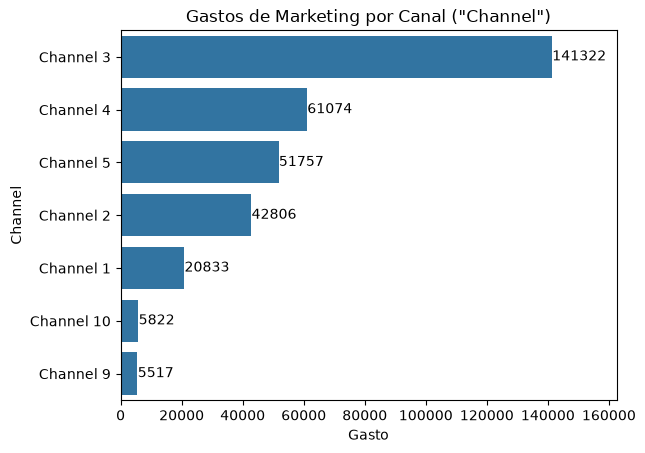

In [39]:
# Gráfico de los gastos de marketing por canal
ax = sns.barplot(
    data=total_costs_by_source,
    x="costs",
    y="channel"
)

# Agregar valores al final de cada barra
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 100,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}',
        va='center'
    )

ax.set_xlim(0, total_costs_by_source['costs'].max() * 1.15)

plt.title('Gastos de Marketing por Canal ("Channel")')
plt.xlabel("Gasto")
plt.ylabel("Channel")
plt.show()

In [40]:
# Calculo de los gastos a lo largo del tiempo
costs["cost_month"] = costs["dt"].dt.to_period("M")

costs_by_month = (
    costs.groupby("cost_month")["costs"]
    .sum()
).reset_index()

costs_by_month["cost_month"] = costs_by_month["cost_month"].dt.to_timestamp()

costs_by_month

,cost_month,costs
0,2017-06-01,18015.00
1,2017-07-01,18240.59
2,2017-08-01,14790.54
3,2017-09-01,24368.91
4,2017-10-01,36322.88
5,2017-11-01,37907.88
6,2017-12-01,38315.35
7,2018-01-01,33518.52
8,2018-02-01,32723.03
9,2018-03-01,30415.27


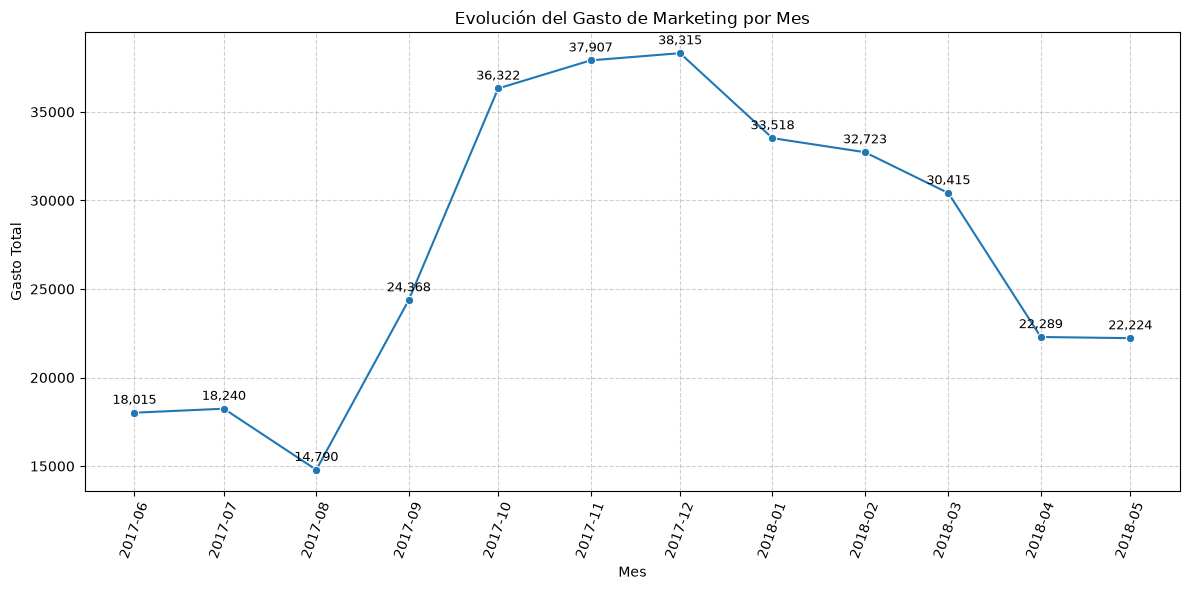

In [41]:
# Gráfico para presentar el gasto mensual a lo largo del tiempo
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=costs_by_month,
    x="cost_month",
    y="costs",
    marker="o"
)

# Agregar etiquetas de valor en cada punto
for x, y in zip(costs_by_month["cost_month"], costs_by_month["costs"]):
    ax.text(
        x,
        y + 500,                 # pequeño desplazamiento vertical
        f"{int(y):,}",           # formato con separador de miles
        ha="center",
        fontsize=9
    )

ax.set_title("Evolución del Gasto de Marketing por Mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Gasto Total")

ax.set_xticks(costs_by_month["cost_month"])
ax.set_xticklabels(
    costs_by_month["cost_month"].dt.strftime("%Y-%m"), rotation=70)

ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [42]:
# Calculo del numero de usuarios adquiridos por canal
users_by_source = (
    visits_clean
    .groupby("source_id")["uid"]
    .nunique()
    .reset_index()
)
users_by_source.columns = ["source_id", "n_users"]
users_by_source

,source_id,n_users
0,1,9469
1,2,17616
2,3,66116
3,4,72346
4,5,49237
5,6,2
6,7,32
7,9,6448
8,10,6903


In [43]:
# Calculo del numero de compradores adquiridos por canal
buyers_by_source = (
    visits_clean[visits_clean["first_purchase"].notna()]
    .groupby("source_id")["uid"]
    .nunique()
    .reset_index()
)

buyers_by_source.columns = ["source_id", "n_buyers"]
buyers_by_source

,source_id,n_buyers
0,1,2899
1,2,3506
2,3,10473
3,4,10296
4,5,6931
5,7,1
6,9,1088
7,10,1329


In [44]:
# Calculo del "CAC" por canal
cac_by_source = total_costs_by_source.merge(
    buyers_by_source, on="source_id", how="outer")

cac_by_source["cac"] = (
    cac_by_source["costs"] / cac_by_source["n_buyers"]
).round(4)

# Completar el campo cac con 0 para canales organicos
cac_by_source["cac"] = cac_by_source["cac"].fillna(0)


cac_by_source = cac_by_source.sort_values("cac", ascending=False)

cac_by_source

,source_id,costs,channel,n_buyers,cac
2,3,141321.63,Channel 3,10473,13.4939
1,2,42806.04,Channel 2,3506,12.2094
4,5,51757.10,Channel 5,6931,7.4675
0,1,20833.27,Channel 1,2899,7.1864
3,4,61073.60,Channel 4,10296,5.9318
6,9,5517.49,Channel 9,1088,5.0712
7,10,5822.49,Channel 10,1329,4.3811
5,7,NaN,NaN,1,0.0000


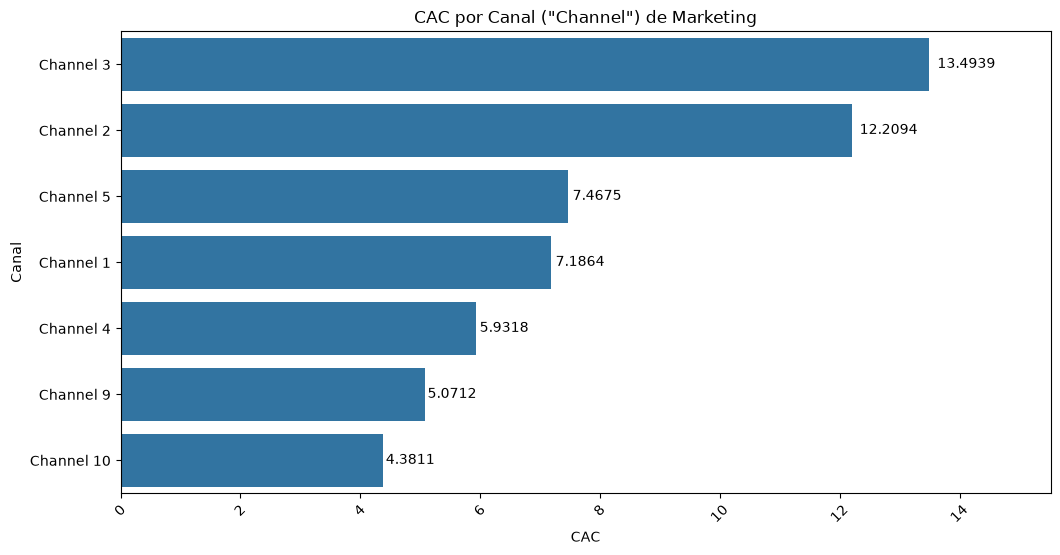

In [45]:

# Gráfico de CAC por Canal de marketing
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=cac_by_source,
    x="cac",
    y="channel"
)

# Agregar valores al final de cada barra
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + (width * .01),
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center'
    )
ax.set_xlim(0, cac_by_source['cac'].max() * 1.15)
plt.xticks(rotation=45)
plt.title('CAC por Canal ("Channel") de Marketing')
plt.xlabel("CAC")
plt.ylabel("Canal")
plt.show()

In [46]:
# Análisis para responder a la pregunta ¿Cuán rentables eran las inversiones? (ROMI)

# Calculo del ROMI
report = ltv_by_source.merge(cac_by_source, on="source_id", how="outer")

# Calculo del ROMI
report["romi"] = report["ltv"] / report["cac"]

report = report.sort_values("romi", ascending=False)

report

,source_id,ltv,costs,channel,n_buyers,cac,romi
5,7,1.22,NaN,NaN,1,0.0000,inf
0,1,10.72,20833.27,Channel 1,2899,7.1864,1.491707
1,2,13.38,42806.04,Channel 2,3506,12.2094,1.095877
6,9,5.29,5517.49,Channel 9,1088,5.0712,1.043146
4,5,7.59,51757.10,Channel 5,6931,7.4675,1.016404
3,4,5.51,61073.60,Channel 4,10296,5.9318,0.928892
7,10,3.35,5822.49,Channel 10,1329,4.3811,0.764648
2,3,5.20,141321.63,Channel 3,10473,13.4939,0.385359


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">
    

## Conclusiones Parte 3 Análisis de Marketing
- Durante el período analizado se invirtieron 329,131.62 en marketing. <br>
La inversión estuvo altamente concentrada en Channel 3, que absorbió aproximadamente el 43% del presupuesto total, seguido por Channel 4 y Channel 5. El resto de los canales recibió una proporción significativamente menor, lo que indica una estrategia de asignación focalizada.
En términos temporales, el gasto mostró una fase de crecimiento hasta alcanzar su punto máximo en el último trimestre de 2017, con niveles cercanos a 38,000 mensuales, seguido de una reducción progresiva durante 2018.
- El análisis muestra diferencias claras en el costo real de adquisición de clientes (compradores):
Channel 3 (13.49) presenta el CAC más alto, convirtiéndose en el canal más costoso para adquirir un cliente que efectivamente compra.
    - Le siguen Channel 2 (12.21) y Channel 5 (7.47), también con niveles elevados de costo por comprador.
    - Channel 1 (7.19) y Channel 4 (5.93) muestran un CAC intermedio.
    - Channel 9 (5.07) y Channel 10 (4.38) son los canales pagados más eficientes en términos de costo por cliente real.
    - Channel 7 (0.00) no registra costos (canal orgánico), aunque su volumen es marginal.
    - Channel 6 no aparece con compradores, por lo que no genera adquisición efectiva.

    En términos estratégicos:
    - Los canales con CAC inferior a 5 representan actualmente las fuentes pagadas más eficientes para adquirir compradores. <br>
    - Los canales con CAC entre 5 y 8 requieren monitoreo y optimización.
    - Los canales con CAC superior a 10 deben revisarse de forma prioritaria, ya que implican un costo elevado por cliente adquirido y podrían comprometer la rentabilidad si el LTV no compensa esa inversión.

- El análisis de ROMI muestra que no todas las fuentes con inversión fueron rentables (ROMI > 1). Existen diferencias claras en desempeño entre canales pagados:
    - Channel 1 (1.49) presenta el nivel de rentabilidad más alto, siendo el canal con mejor retorno por unidad invertida.
    - Channel 2 (1.10) y Channel 9 (1.04) también muestran rentabilidad positiva, aunque más moderada.
    - Channel 5 (1.02) se encuentra prácticamente en el punto de equilibrio, con un margen muy reducido.
    - Channel 4 (0.93) y Channel 10 (0.76) ya no son rentables, pues el retorno generado no cubre completamente el costo de adquisición.
    - Channel 3 (0.39) es claramente el canal menos rentable, generando un retorno significativamente inferior a la inversión realizada.
    - Channel 7 no presenta valores interpretables de ROMI al no registrar inversión (canal orgánico).

    La inversión no fue globalmente rentable. Solo algunos canales superan el umbral de rentabilidad (ROMI > 1), y en varios casos el margen es mínimo. Existe una necesidad clara de: <br>
    - Reasignar presupuesto hacia Channel 1, Channel 2 y Channel 9. <br>
    - Evaluar críticamente Channel 3, dado su bajo desempeño relativo. <br>
    - Revisar la eficiencia de Channel 4 y Channel 10, que actualmente destruyen valor. <br>

    En este escenario, la optimización presupuestal deja de ser una oportunidad y se convierte en una prioridad estratégica.

</div>

<div style="border-left: 10px solid #4CAF50;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;
text-align: justify;">



## Conclusión Final del Proyecto

El análisis integral del comportamiento de usuarios, desempeño comercial y eficiencia de marketing permite caracterizar el modelo de negocio como altamente dependiente de adquisición constante, con ciclos de decisión cortos y bajo valor promedio por cliente.

Desde la perspectiva de uso, el servicio mantiene una base estable de aproximadamente 900 usuarios activos diarios, que escalan a más de 23,000 usuarios activos mensuales. Sin embargo, el nivel de stickiness confirma que el servicio no es de uso cotidiano: solo el 4% de los usuarios activos mensuales interactúa diariamente. Las sesiones son breves (mediana ~5 minutos), lo que evidencia un comportamiento orientado a una acción puntual. El usuario entra con intención clara y toma decisiones rápidamente.

En ventas, la conversión ocurre mayoritariamente de forma inmediata: el 75% de los usuarios compra dentro de los primeros 2 días. Esto representa una fortaleza operativa, ya que reduce la necesidad de estrategias de remarketing. Sin embargo, la recurrencia es limitada: la mediana es 1 pedido por usuario y el 75% de los usuarios realiza solo una compra. El promedio de 1.38 pedidos confirma que el crecimiento depende principalmente de la captación de nuevos clientes.

El ticket promedio (5.0) está influenciado por outliers, mientras que la mediana (2.5) refleja un comportamiento típico de bajo gasto. El 90% de las compras no supera 9.17, lo que confirma que el modelo opera con ingresos unitarios reducidos. En consecuencia, el volumen es el principal motor financiero del negocio.

En términos generales, el ingreso total del período fue 252,057, mientras que el gasto total en marketing ascendió a 329,131. Esto implica que, a nivel global, el gasto en adquisición superó los ingresos generados en el mismo período analizado.

El análisis de rentabilidad por canal (ROMI) muestra un escenario en donde solo Channel 1 (ROMI 1.49), Channel 2 (1.10), Channel 9 (1.04) y de forma marginal Channel 5 (1.02) generan retornos superiores a la inversión. <br> <br>

En contraste, Channel 4 (0.93), Channel 10 (0.76) y especialmente Channel 3 (0.39) no recuperan el capital invertido en el período evaluado.
Channel 3, además de concentrar una proporción significativa del presupuesto total, presenta el desempeño más bajo en términos de retorno relativo, lo que impacta de forma directa en la rentabilidad global del negocio.

En conjunto, el negocio demuestra capacidad de conversión eficiente y canales puntualmente rentables, pero enfrenta un desafío estructural en la asignación y eficiencia del gasto de marketing. Bajo la configuración actual, el crecimiento no garantiza rentabilidad. <br>
La sostenibilidad financiera dependerá de una redistribución estratégica del presupuesto hacia los canales con retorno positivo y de la optimización o replanteamiento de aquellos que actualmente destruyen valor.

---
## Insights Principales
---
### 1. La conversión ocurre casi inmediatamente después de la primera visita.
El 75% de los usuarios realiza su primera compra dentro de los primeros 2 días y la mediana de tiempo a conversión es 0 días. Esto indica una ventana de decisión extremadamente corta. <br>
**Recomendación:** Optimizar el primer impacto publicitario y la experiencia inicial del sitio (UX, claridad de oferta, urgencia) ya que la probabilidad de conversión disminuye rápidamente después del primer contacto.

---
### 2. El desempeño de las cohortes muestra una disminución en la calidad del tráfico durante 2018

Las cohortes de junio (22.05%) y julio de 2017 (18.71%) presentan las tasas de conversión más altas, mientras que las cohortes de 2018 muestran una tendencia descendente, con valores entre 12% y 15%. Esto sugiere una posible reducción en la calidad del tráfico adquirido o cambios en la efectividad de las estrategias de adquisición. <br>
Recomendación: Analizar los cambios en segmentación, canales o campañas implementados en 2018 y replicar las condiciones de adquisición de las cohortes con mejor desempeño para recuperar niveles de conversión superiores.

---
### 3. Existe un desbalance entre ingreso total y gasto total en marketing
El ingreso total del período (252,057.2) es menor al gasto total en marketing (329,131.62), lo que implica que la inversión superó los ingresos generados en el mismo periodo.<br>
**Recomendación:** Revisar la estructura de inversión y priorizar canales que ya demuestran rentabilidad positiva, eliminando o corrigiendo aquellos con retorno inferior a 1.

---
### 4. La inversión está concentrada en un canal claramente no rentable

Channel 3 absorbió aproximadamente el 43% del presupuesto, pero presenta un ROMI inferior a 1 (0.39), lo que implica que no recupera la inversión realizada.<br>
**Recomendación:** Reducir de manera inmediata la asignación de presupuesto en Channel 3 hasta rediseñar su estrategia, ya que actualmente opera con rentabilidad negativa.

---
### 5. La rentabilidad por canal es ajustada y frágil

Solo algunos canales superan ligeramente el punto de equilibrio (ROMI > 1), como Channel 1, Channel 2, Channel 9 y Channel 5, pero con márgenes reducidos. Mientras que los otros canales operan por debajo del punto de equilibrio.<br>
**Recomendación:** Reasignar gradualmente presupuesto hacia los canales con mejor desempeño relativo, monitoreando el impacto incremental en CAC y ROMI para evitar deterioro de eficiencia.

**En conjunto, estos insights muestran que el desafío principal no es incrementar la inversión, sino estabilizar la rentabilidad. Aunque el negocio tiene buena capacidad de conversión y decisión rápida del usuario, la estructura actual de marketing presenta ineficiencias críticas. El crecimiento sostenible solo será posible mediante una reasignación del presupuesto hacia canales con retorno comprobado y la corrección inmediata de aquellos que operan con rentabilidad negativa.**

</div>